<a href="https://colab.research.google.com/github/nikhilratagal03/Bank-Marketing-Analysis/blob/main/Diwali_sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/data1.csv", encoding='latin1')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [ ]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [ ]:
df.drop(["Status","unnamed1"],axis=1,inplace=True)

In [ ]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [ ]:
df.dropna(subset=["Amount"],inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Amount'] = df['Amount'].astype(int)

In [ ]:
df['Gender'] = df['Gender'].replace({'F': 'Female', 'M': 'Male'})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11231 non-null  int64 
 1   Cust_name         11231 non-null  object
 2   Product_ID        11231 non-null  object
 3   Gender            11231 non-null  object
 4   Age Group         11231 non-null  object
 5   Age               11231 non-null  int64 
 6   Marital_Status    11231 non-null  int64 
 7   State             11231 non-null  object
 8   Zone              11231 non-null  object
 9   Occupation        11231 non-null  object
 10  Product_Category  11231 non-null  object
 11  Orders            11231 non-null  int64 
 12  Amount            11231 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


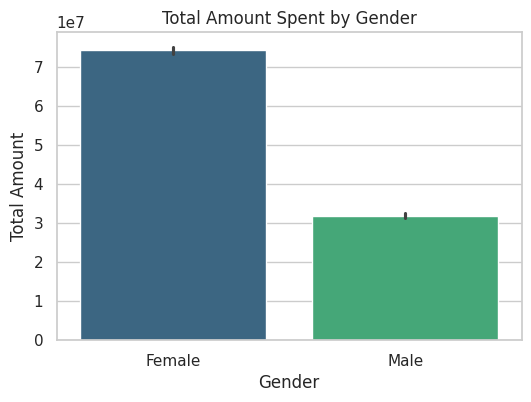

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Amount', data=df, estimator='sum', hue='Gender',
            palette='viridis', legend=False)
plt.title('Total Amount Spent by Gender')
plt.ylabel('Total Amount')
plt.show()

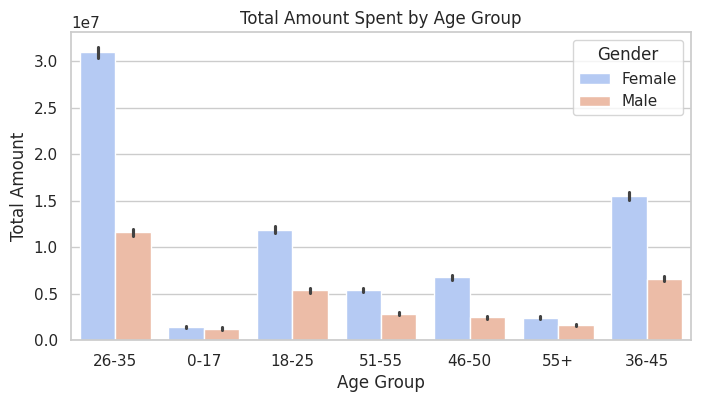

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x='Age Group', y='Amount', data=df, estimator='sum', hue='Gender',
            palette='coolwarm')
plt.title('Total Amount Spent by Age Group')
plt.ylabel('Total Amount')
plt.show()

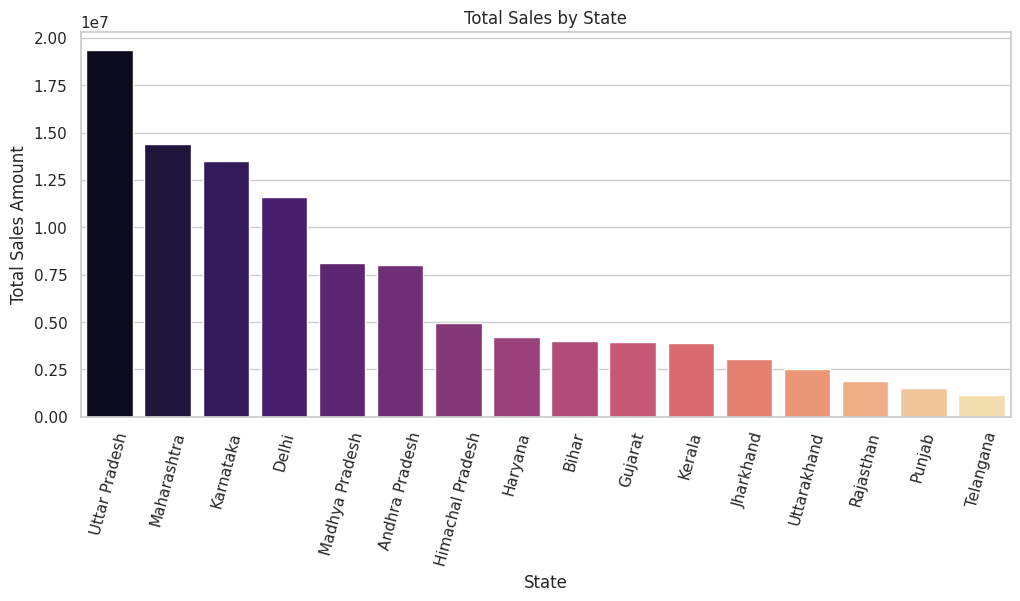

In [ ]:
sales_state = df.groupby('State', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(x='State', y='Amount', data=sales_state, hue='State', palette='magma', legend=False)
plt.title('Total Sales by State')
plt.xticks(rotation=75)
plt.ylabel('Total Sales Amount')
plt.show()

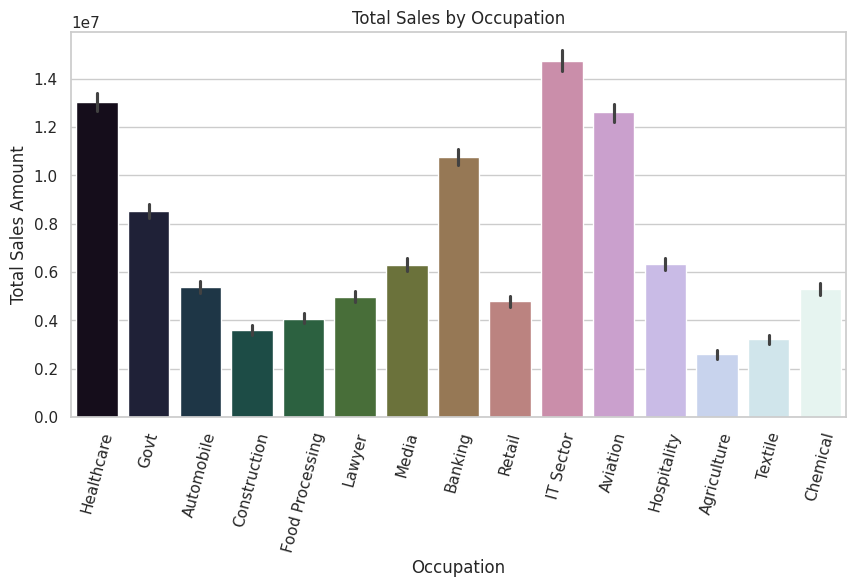

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Occupation', y='Amount', data=df, estimator='sum', hue='Occupation',
            palette='cubehelix', legend=False)
plt.title('Total Sales by Occupation')
plt.xticks(rotation=75)
plt.ylabel('Total Sales Amount')
plt.show()

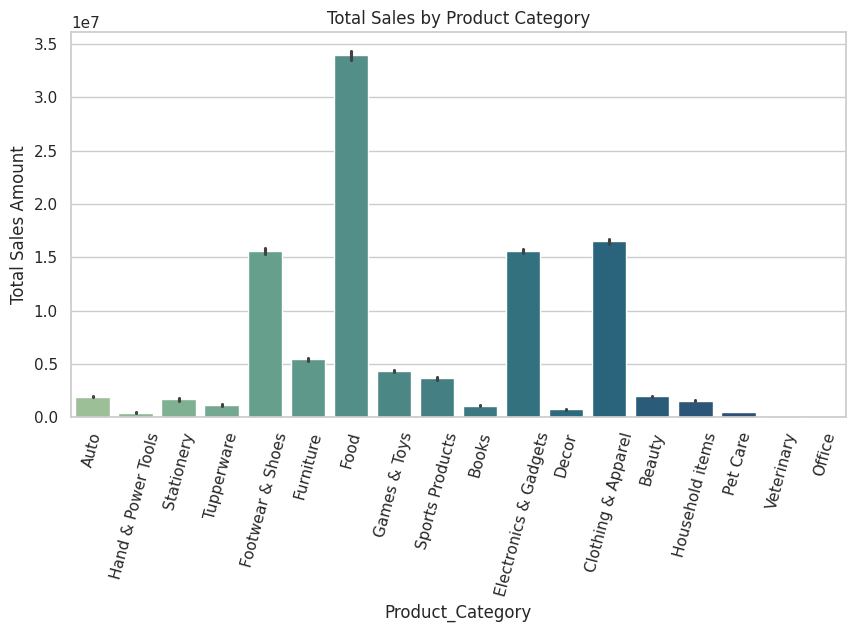

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Product_Category', y='Amount', data=df, estimator='sum', hue='Product_Category',
            palette='crest', legend=False)
plt.title('Total Sales by Product Category')
plt.xticks(rotation=75)
plt.ylabel('Total Sales Amount')
plt.show()

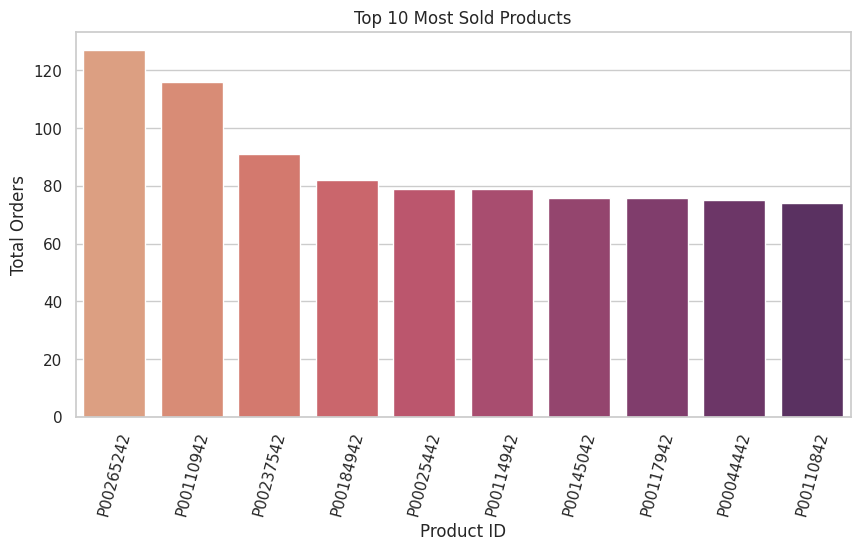

In [ ]:
top_products = df.groupby('Product_ID')['Orders'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.index, y=top_products.values, hue=top_products.index,
            palette='flare', legend=False)
plt.title('Top 10 Most Sold Products')
plt.xlabel('Product ID')
plt.ylabel('Total Orders')
plt.xticks(rotation=75)
plt.show()